In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet("cleaned_crime_data.parquet")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (3046607, 21)


,cmplnt_fr_dt,cmplnt_fr_tm,cmplnt_to_dt,cmplnt_to_tm,rpt_dt,ky_cd,ofns_desc,pd_cd,pd_desc,crm_atpt_cptd_cd,...,boro_nm,addr_pct_cd,loc_of_occur_desc,prem_typ_desc,latitude,longitude,year,month,day_of_week,hour
0,2020-01-01,2026-08-21 00:01:00,2021-06-30,2026-08-21 23:59:00,2021-07-02,340,FRAUDS,718.0,"FRAUD,UNCLASSIFIED-MISDEMEANOR",COMPLETED,...,BRONX,47.0,INSIDE,RESIDENCE-HOUSE,40.898612,-73.867384,2020,1,2,0
1,2020-01-01,2026-08-21 08:00:00,2020-02-27,2026-08-21 08:00:00,2020-02-27,112,THEFT-FRAUD,739.0,"FRAUD,UNCLASSIFIED-FELONY",COMPLETED,...,STATEN ISLAND,121.0,INSIDE,RESIDENCE-HOUSE,40.632157,-74.165787,2020,1,2,8
2,2020-01-01,2026-08-21 16:30:00,NaT,NaT,2020-01-01,578,HARRASSMENT 2,637.0,"HARASSMENT,SUBD 1,CIVILIAN",COMPLETED,...,STATEN ISLAND,122.0,INSIDE,RESIDENCE-HOUSE,40.565063,-74.098826,2020,1,2,16
3,2020-01-01,2026-08-21 00:30:00,2020-01-01,2026-08-21 00:33:00,2020-01-01,355,OFFENSES AGAINST THE PERSON,115.0,RECKLESS ENDANGERMENT 2,COMPLETED,...,STATEN ISLAND,122.0,OPPOSITE OF,RESIDENCE-HOUSE,40.553653,-74.149886,2020,1,2,0
4,2020-01-01,2026-08-21 03:00:00,2020-01-01,2026-08-21 03:30:00,2020-01-01,365,ADMINISTRATIVE CODE,877.0,UNLAWFUL DISCLOSURE OF AN INTIMATE IMAGE,COMPLETED,...,BROOKLYN,68.0,INSIDE,RESIDENCE - APT. HOUSE,40.622500,-74.025503,2020,1,2,3


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3046607 entries, 0 to 3046606
Data columns (total 21 columns):
 #   Column             Dtype         
---  ------             -----         
 0   cmplnt_fr_dt       datetime64[us]
 1   cmplnt_fr_tm       datetime64[us]
 2   cmplnt_to_dt       datetime64[us]
 3   cmplnt_to_tm       datetime64[us]
 4   rpt_dt             datetime64[us]
 5   ky_cd              int64         
 6   ofns_desc          str           
 7   pd_cd              float64       
 8   pd_desc            str           
 9   crm_atpt_cptd_cd   str           
 10  law_cat_cd         str           
 11  boro_nm            str           
 12  addr_pct_cd        float64       
 13  loc_of_occur_desc  str           
 14  prem_typ_desc      str           
 15  latitude           float64       
 16  longitude          float64       
 17  year               int32         
 18  month              int32         
 19  day_of_week        int32         
 20  hour               int32         
d

In [3]:
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False))
df.describe(include="all").T


Columns:
['cmplnt_fr_dt', 'cmplnt_fr_tm', 'cmplnt_to_dt', 'cmplnt_to_tm', 'rpt_dt', 'ky_cd', 'ofns_desc', 'pd_cd', 'pd_desc', 'crm_atpt_cptd_cd', 'law_cat_cd', 'boro_nm', 'addr_pct_cd', 'loc_of_occur_desc', 'prem_typ_desc', 'latitude', 'longitude', 'year', 'month', 'day_of_week', 'hour']

Missing values:
cmplnt_to_dt         201546
cmplnt_to_tm         199744
pd_cd                  2308
addr_pct_cd              92
latitude                 41
longitude                41
rpt_dt                    0
cmplnt_fr_dt              0
cmplnt_fr_tm              0
pd_desc                   0
crm_atpt_cptd_cd          0
ofns_desc                 0
ky_cd                     0
boro_nm                   0
law_cat_cd                0
prem_typ_desc             0
loc_of_occur_desc         0
year                      0
month                     0
day_of_week               0
hour                      0
dtype: int64


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
cmplnt_fr_dt,3046607,NaN,NaN,NaN,2023-03-11 11:52:29.099441,2020-01-01 00:00:00,2021-10-24 00:00:00,2023-04-13 00:00:00,2024-08-22 00:00:00,2025-12-31 00:00:00,NaN
cmplnt_fr_tm,3046607,NaN,NaN,NaN,2026-08-21 13:34:11.655050,2026-08-21 00:00:00,2026-08-21 09:19:00,2026-08-21 14:34:00,2026-08-21 18:47:00,2026-08-21 23:59:00,NaN
cmplnt_to_dt,2845061,NaN,NaN,NaN,2023-03-27 04:55:46.908344,2020-01-01 00:00:00,2021-11-13 00:00:00,2023-05-05 00:00:00,2024-09-05 00:00:00,2052-11-08 00:00:00,NaN
cmplnt_to_tm,2846863,NaN,NaN,NaN,2026-08-21 13:31:46.710234,2026-08-21 00:00:00,2026-08-21 09:00:00,2026-08-21 14:20:00,2026-08-21 18:35:00,2026-08-21 23:59:00,NaN
rpt_dt,3046607,NaN,NaN,NaN,2023-03-18 23:13:51.355144,2020-01-01 00:00:00,2021-11-01 00:00:00,2023-04-21 00:00:00,2024-08-29 00:00:00,2025-12-31 00:00:00,NaN
ky_cd,3046607.0,NaN,NaN,NaN,302.400941,101.0,117.0,341.0,351.0,881.0,159.699729
ofns_desc,3046607,69,PETIT LARCENY,600712,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pd_cd,3044299.0,NaN,NaN,NaN,414.019167,100.0,258.0,357.0,638.0,969.0,223.179774
pd_desc,3046607,400,"HARASSMENT,SUBD 3,4,5",359672,NaN,NaN,NaN,NaN,NaN,NaN,NaN
crm_atpt_cptd_cd,3046607,3,COMPLETED,3003005,NaN,NaN,NaN,NaN,NaN,NaN,NaN


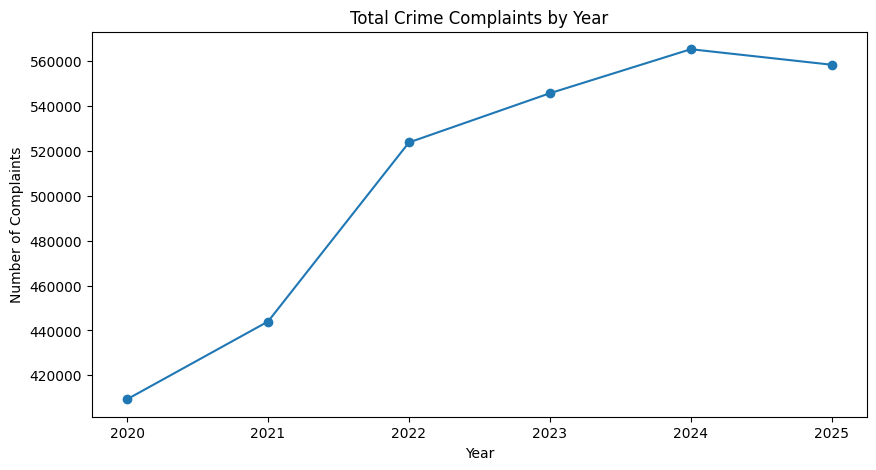

year
2020    409381
2021    444006
2022    523785
2023    545706
2024    565320
2025    558409
Name: count, dtype: int64


In [4]:
yearly_crimes = df["year"].value_counts().sort_index()

plt.figure(figsize=(10, 5))

plt.plot(
    yearly_crimes.index,
    yearly_crimes.values,
    marker="o"
)

plt.title("Total Crime Complaints by Year")
plt.xlabel("Year")
plt.ylabel("Number of Complaints")
plt.xticks(yearly_crimes.index)

plt.show()

print(yearly_crimes)

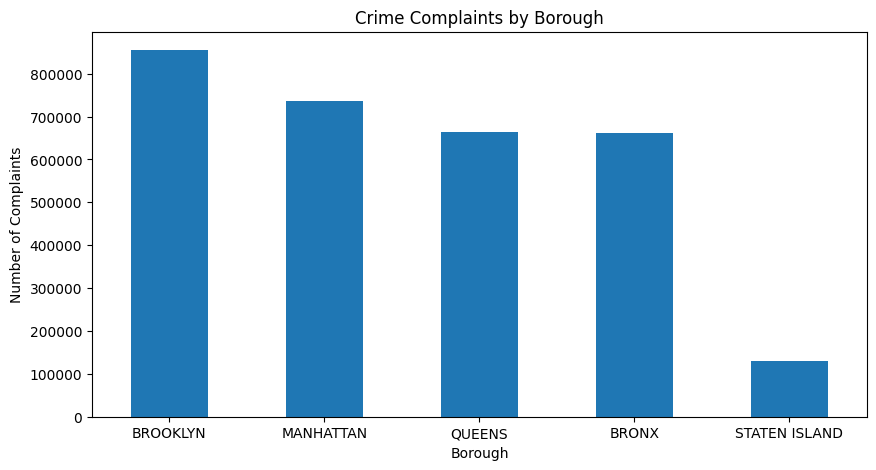

boro_nm
BROOKLYN         855105
MANHATTAN        737095
QUEENS           663288
BRONX            660929
STATEN ISLAND    130190
Name: count, dtype: int64


In [5]:
borough_crimes = df["boro_nm"].value_counts()

plt.figure(figsize=(10, 5))

borough_crimes.plot(
    kind="bar"
)

plt.title("Crime Complaints by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=0)

plt.show()

print(borough_crimes)

ofns_desc
PETIT LARCENY                     600712
HARRASSMENT 2                     474760
ASSAULT 3 & RELATED OFFENSES      313258
GRAND LARCENY                     272855
CRIMINAL MISCHIEF & RELATED OF    251578
FELONY ASSAULT                    149699
OFF. AGNST PUB ORD SENSBLTY &     104399
VEHICLE AND TRAFFIC LAWS          100770
MISCELLANEOUS PENAL LAW            97993
ROBBERY                            92962
BURGLARY                           83604
GRAND LARCENY OF MOTOR VEHICLE     76582
DANGEROUS DRUGS                    71041
SEX CRIMES                         43319
DANGEROUS WEAPONS                  43309
Name: count, dtype: int64


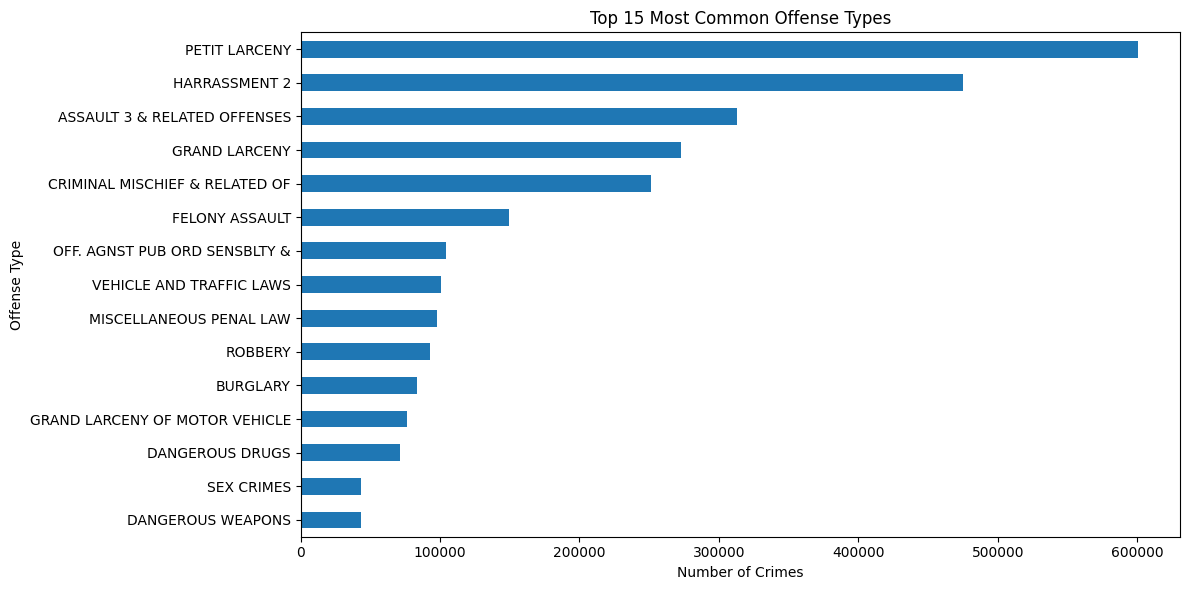

In [6]:
import matplotlib.pyplot as plt

# Top 15 offense types
top_offenses = df["ofns_desc"].value_counts().head(15)

print(top_offenses)

# Plot
plt.figure(figsize=(12, 6))

top_offenses.sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Most Common Offense Types")
plt.xlabel("Number of Crimes")
plt.ylabel("Offense Type")

plt.tight_layout()
plt.show()

law_cat_cd
MISDEMEANOR    1551613
FELONY         1007910
VIOLATION       487084
Name: count, dtype: int64


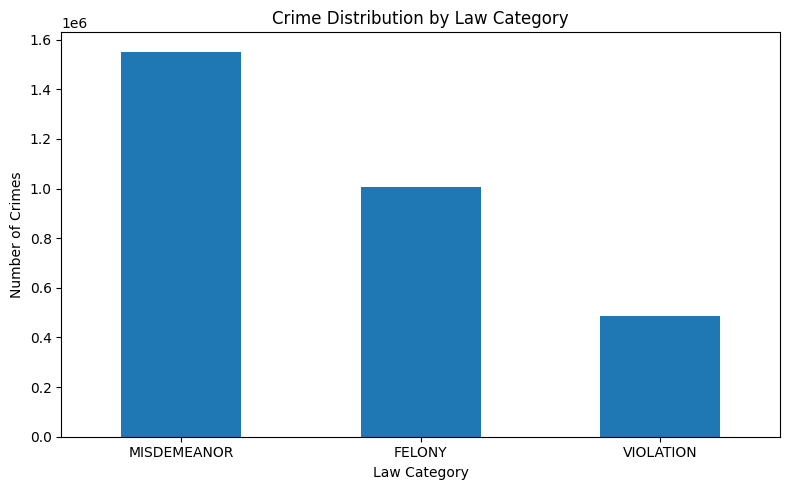

In [7]:
import matplotlib.pyplot as plt

# Count crime categories
crime_categories = df["law_cat_cd"].value_counts()

print(crime_categories)

# Plot
plt.figure(figsize=(8, 5))

crime_categories.plot(
    kind="bar"
)

plt.title("Crime Distribution by Law Category")
plt.xlabel("Law Category")
plt.ylabel("Number of Crimes")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

month
1     245668
2     224535
3     248669
4     235963
5     261545
6     260463
7     268815
8     268174
9     261406
10    272083
11    255846
12    243440
dtype: int64


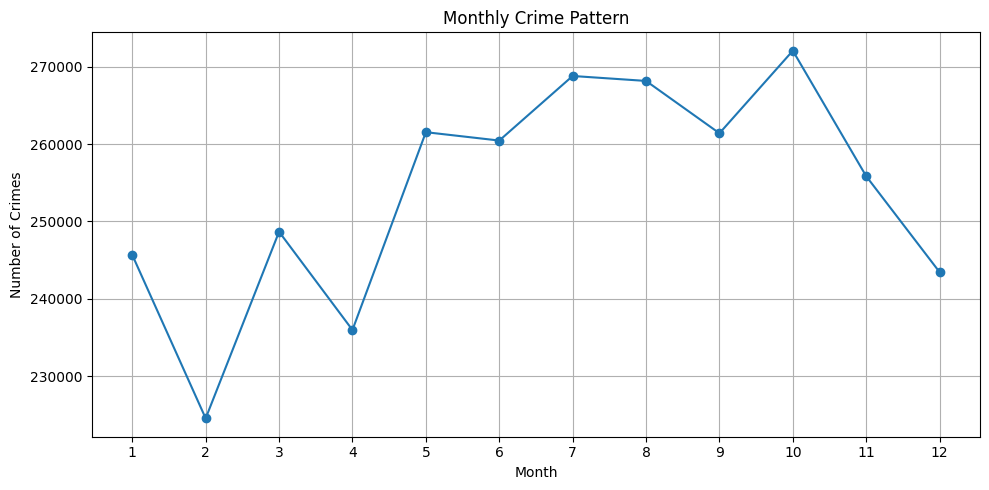

In [8]:
import matplotlib.pyplot as plt

monthly_crimes = df.groupby("month").size()

print(monthly_crimes)

plt.figure(figsize=(10, 5))

monthly_crimes.plot(kind="line", marker="o")

plt.title("Monthly Crime Pattern")
plt.xlabel("Month")
plt.ylabel("Number of Crimes")
plt.xticks(range(1, 13))

plt.grid(True)
plt.tight_layout()
plt.show()

day_of_week
Monday       426001
Tuesday      439818
Wednesday    452134
Thursday     440606
Friday       458322
Saturday     426490
Sunday       403236
Name: count, dtype: int64


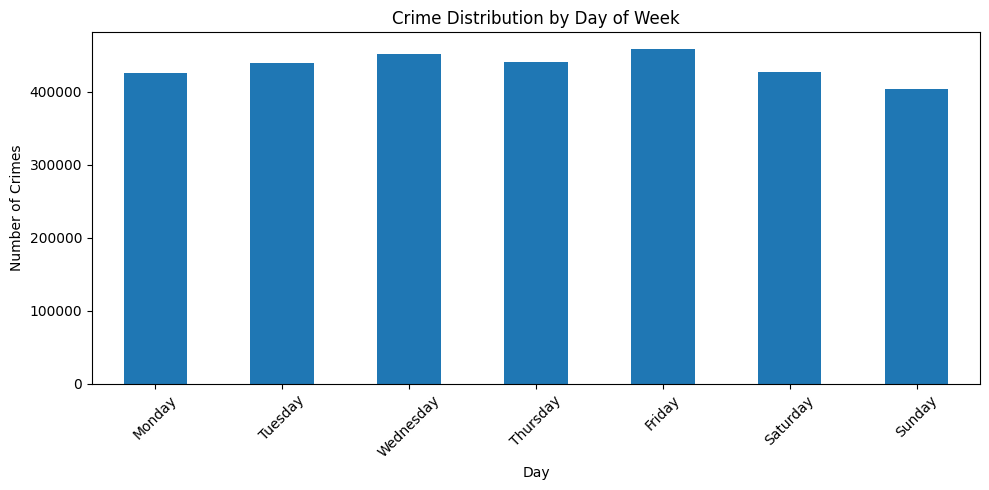

In [9]:
import matplotlib.pyplot as plt

day_names = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

daily_crimes = df["day_of_week"].value_counts().sort_index()
daily_crimes.index = daily_crimes.index.map(day_names)

print(daily_crimes)

plt.figure(figsize=(10, 5))

daily_crimes.plot(kind="bar")

plt.title("Crime Distribution by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Crimes")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

hour
0     132080
1      92268
2      76939
3      65985
4      56498
5      45567
6      49940
7      72933
8     109969
9     117853
10    129545
11    134290
12    171858
13    149874
14    165483
15    183882
16    183416
17    185244
18    183228
19    174145
20    166647
21    147595
22    134285
23    117083
Name: count, dtype: int64


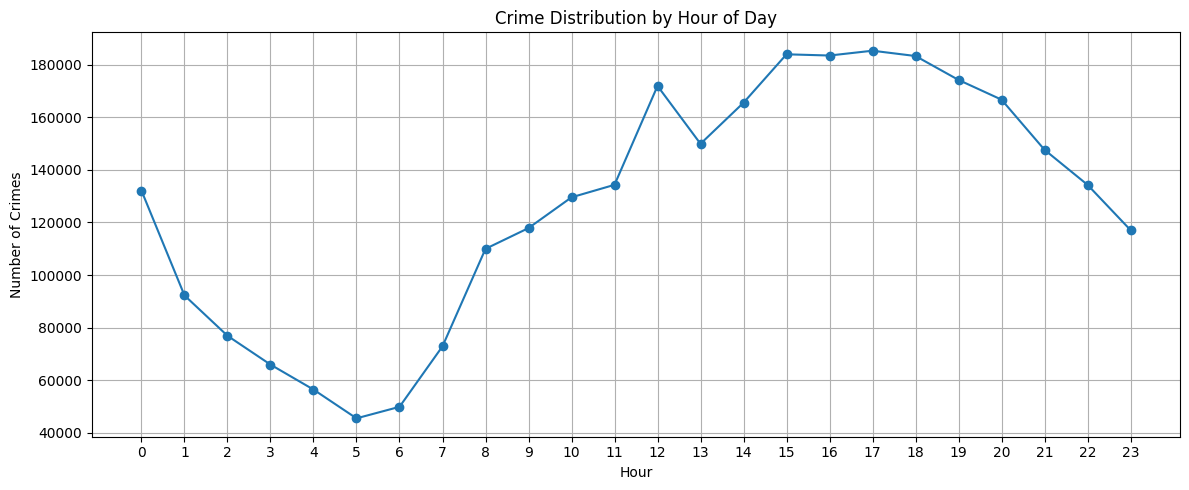

In [10]:
import matplotlib.pyplot as plt

hourly_crimes = df["hour"].value_counts().sort_index()

print(hourly_crimes)

plt.figure(figsize=(12, 5))

hourly_crimes.plot(kind="line", marker="o")

plt.title("Crime Distribution by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Crimes")
plt.xticks(range(24))
plt.grid(True)

plt.tight_layout()
plt.show()

In [11]:
borough_offenses = pd.crosstab(
    df["boro_nm"],
    df["ofns_desc"]
)

# Top 5 offenses for each borough
for borough in borough_offenses.index:
    print(f"\n{'='*50}")
    print(borough)
    print(
        borough_offenses.loc[borough]
        .sort_values(ascending=False)
        .head(5)
    )


BRONX
ofns_desc
HARRASSMENT 2                     108416
PETIT LARCENY                      97885
ASSAULT 3 & RELATED OFFENSES       79959
CRIMINAL MISCHIEF & RELATED OF     55014
GRAND LARCENY                      47200
Name: BRONX, dtype: int64

BROOKLYN
ofns_desc
PETIT LARCENY                     156445
HARRASSMENT 2                     141346
ASSAULT 3 & RELATED OFFENSES       86780
CRIMINAL MISCHIEF & RELATED OF     72386
GRAND LARCENY                      66737
Name: BROOKLYN, dtype: int64

MANHATTAN
ofns_desc
PETIT LARCENY                     189443
GRAND LARCENY                      95255
HARRASSMENT 2                      94122
ASSAULT 3 & RELATED OFFENSES       65563
CRIMINAL MISCHIEF & RELATED OF     53785
Name: MANHATTAN, dtype: int64

QUEENS
ofns_desc
PETIT LARCENY                     135390
HARRASSMENT 2                     104341
ASSAULT 3 & RELATED OFFENSES       68574
CRIMINAL MISCHIEF & RELATED OF     57751
GRAND LARCENY                      55636
Name: QUEENS, dtype

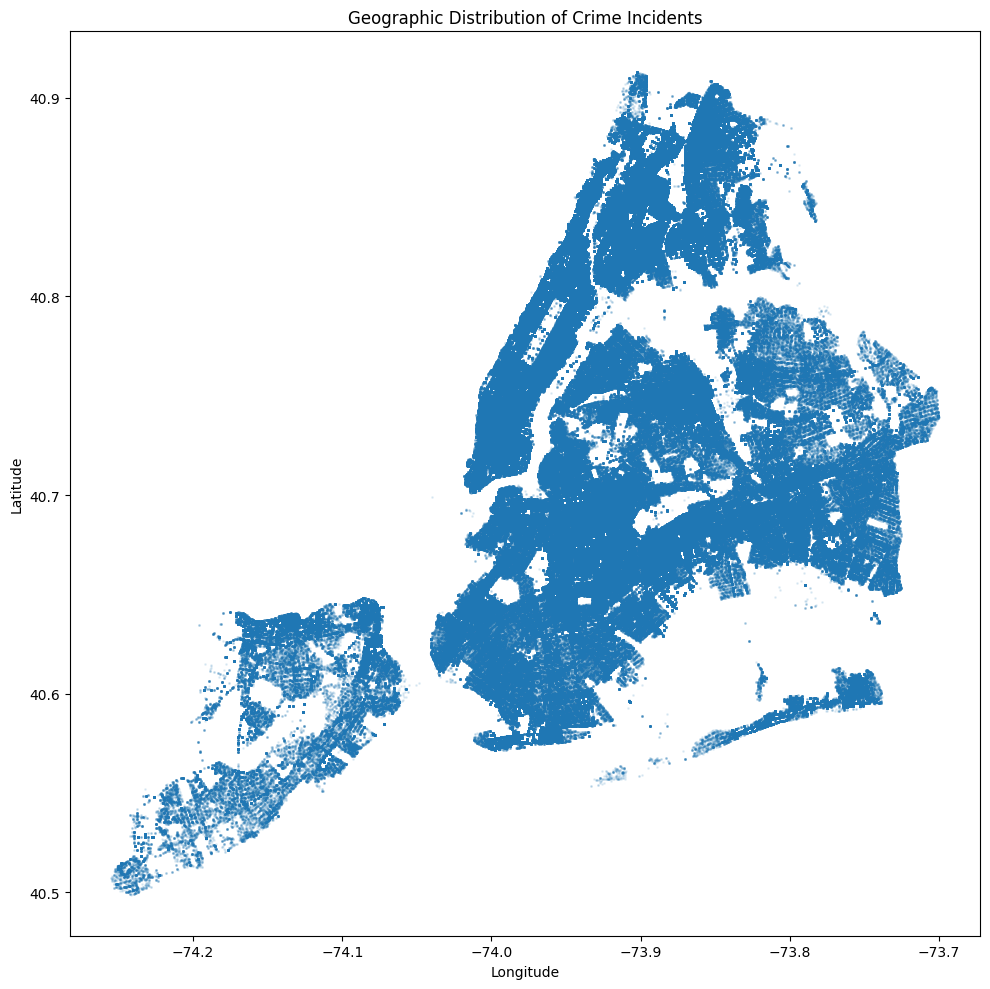

Records used for geographic analysis: 3046566


In [12]:
import matplotlib.pyplot as plt

geo_df = df.dropna(subset=["latitude", "longitude"])

plt.figure(figsize=(10, 10))

plt.scatter(
    geo_df["longitude"],
    geo_df["latitude"],
    s=1,
    alpha=0.1
)

plt.title("Geographic Distribution of Crime Incidents")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.show()

print("Records used for geographic analysis:", len(geo_df))

In [13]:
print("===== EDA SUMMARY =====")

print("\n1. Total crime records:")
print(len(df))

print("\n2. Year with highest crimes:")
print(df["year"].value_counts().idxmax())

print("\n3. Borough with highest crimes:")
print(df["boro_nm"].value_counts().idxmax())

print("\n4. Most common offense:")
print(df["ofns_desc"].value_counts().idxmax())

print("\n5. Most common law category:")
print(df["law_cat_cd"].value_counts().idxmax())

print("\n6. Month with highest crimes:")
print(df["month"].value_counts().idxmax())

print("\n7. Day with highest crimes:")
print(df["day_of_week"].value_counts().idxmax())

print("\n8. Hour with highest crimes:")
print(df["hour"].value_counts().idxmax())

===== EDA SUMMARY =====

1. Total crime records:
3046607

2. Year with highest crimes:
2024

3. Borough with highest crimes:
BROOKLYN

4. Most common offense:
PETIT LARCENY

5. Most common law category:
MISDEMEANOR

6. Month with highest crimes:
10

7. Day with highest crimes:
4

8. Hour with highest crimes:
17
